In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
titanic = sns.load_dataset("titanic")

titanic.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded and saved as titanic.csv")
print("Shape:", titanic.shape)

Titanic dataset loaded and saved as titanic.csv
Shape: (891, 15)


In [3]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded from titanic.csv")
print("Shape:", df.shape)

Dataset loaded from titanic.csv
Shape: (891, 15)


In [4]:
print("----- DATASET INFO -----")
df.info()

print("\n----- DESCRIPTIVE STATISTICS -----")
display(df.describe(include="all"))

print("\n----- DATASET SHAPE -----")
print(df.shape)

----- DATASET INFO -----
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB

----- DESCRIPTIVE STATISTICS -----


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



----- DATASET SHAPE -----
(891, 15)


In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

display(missing_table[missing_table["Missing Count"] > 0])

,Missing Count,Missing Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [6]:
# Make a copy for cleaning
df_clean = df.copy()

# 1. Drop rows with <5% missing values
df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

# 2. Impute age because its missing percentage is between 5% and 30%
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# 3. Drop deck because it has very high missingness
df_clean = df_clean.drop(columns=["deck"])

print("Cleaning completed.")
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Cleaning completed.
Original shape: (891, 15)
Cleaned shape: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


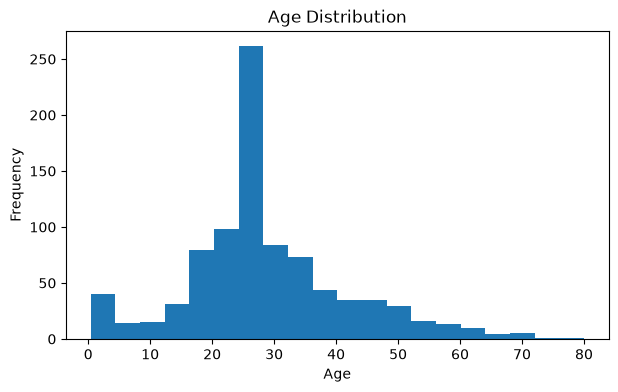

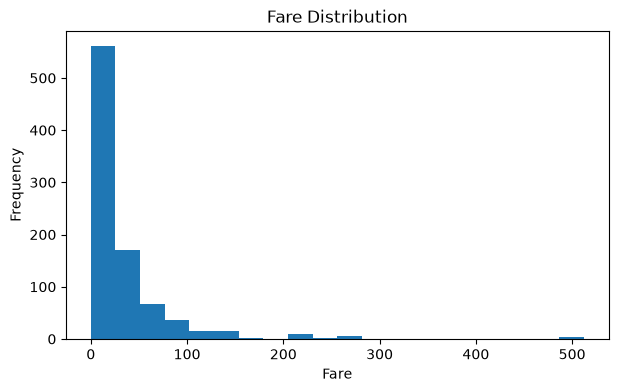

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df_clean["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df_clean["fare"], bins=20)
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Distribution")
plt.show()

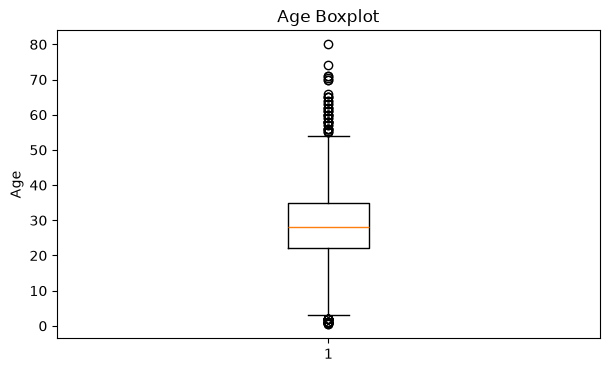

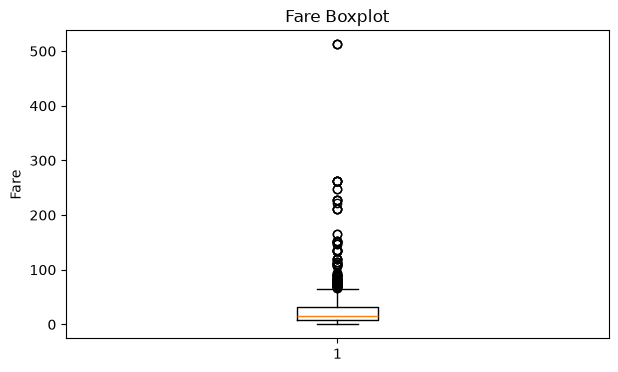

Age IQR outlier count: 65
Fare IQR outlier count: 114


In [8]:
# Boxplots
plt.figure(figsize=(7, 4))
plt.boxplot(df_clean["age"])
plt.ylabel("Age")
plt.title("Age Boxplot")
plt.show()

plt.figure(figsize=(7, 4))
plt.boxplot(df_clean["fare"])
plt.ylabel("Fare")
plt.title("Fare Boxplot")
plt.show()


# IQR outlier counts
def iqr_outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return ((series < lower_bound) | (series > upper_bound)).sum()


age_outliers = iqr_outlier_count(df_clean["age"])
fare_outliers = iqr_outlier_count(df_clean["fare"])

print("Age IQR outlier count:", age_outliers)
print("Fare IQR outlier count:", fare_outliers)

In [9]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]
fare_skew = df_clean["fare"].skew()

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)
print("Fare Skewness:", fare_skew)

if fare_skew > 0:
    print("Conclusion: Fare is positively skewed (right-skewed).")
elif fare_skew < 0:
    print("Conclusion: Fare is negatively skewed (left-skewed).")
else:
    print("Conclusion: Fare is approximately symmetric.")

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05
Fare Skewness: 4.801440211044194
Conclusion: Fare is positively skewed (right-skewed).


In [10]:
male_survival = df_clean.loc[df_clean["sex"] == "male", "survived"].mean()
female_survival = df_clean.loc[df_clean["sex"] == "female", "survived"].mean()

print("Male survival rate:", male_survival)
print("Female survival rate:", female_survival)

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154


In [11]:
id="6s4x2m"
for pclass in sorted(df_clean["pclass"].unique()):
    rate = df_clean.loc[df_clean["pclass"] == pclass, "survived"].mean()
    print(f"Class {pclass} survival rate: {rate:.4f}")

Class 1 survival rate: 0.6262
Class 2 survival rate: 0.4728
Class 3 survival rate: 0.2424


In [12]:
survival_by_sex_class = (
    df_clean
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

survival_by_sex_class["survival_rate"] = (
    survival_by_sex_class["survived"] * 100
)

display(
    survival_by_sex_class[
        ["sex", "pclass", "survival_rate"]
    ]
)

,sex,pclass,survival_rate
0,female,1,96.739130
1,female,2,92.105263
2,female,3,50.000000
3,male,1,36.885246
4,male,2,15.740741
5,male,3,13.544669


In [13]:
corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[corr_cols].corr()

display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


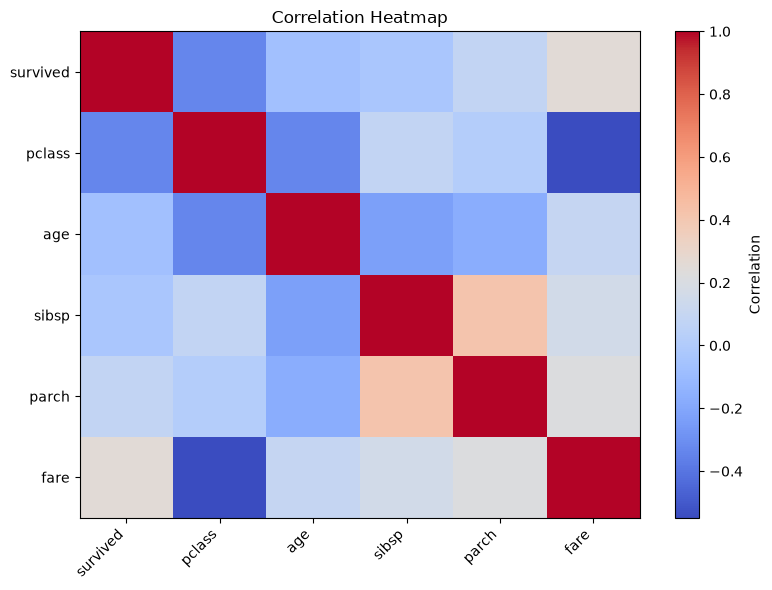

In [14]:
plt.figure(figsize=(8, 6))

plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

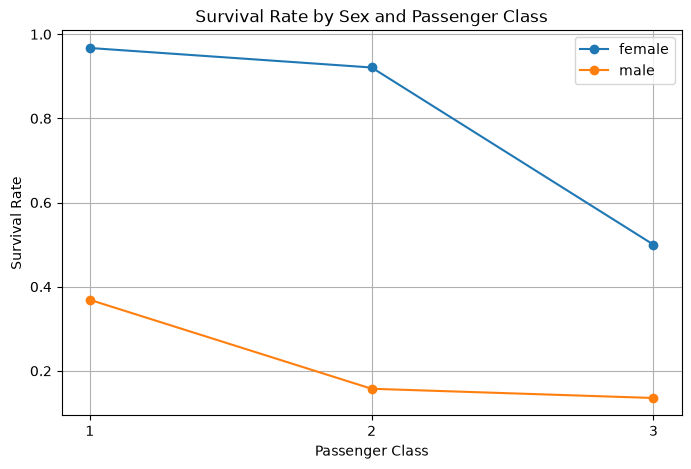

In [15]:
survival_sex_class = (
    df_clean.groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

for sex in survival_sex_class["sex"].unique():
    subset = survival_sex_class[survival_sex_class["sex"] == sex]
    plt.plot(
        subset["pclass"],
        subset["survived"],
        marker="o",
        label=sex
    )

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex and Passenger Class")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

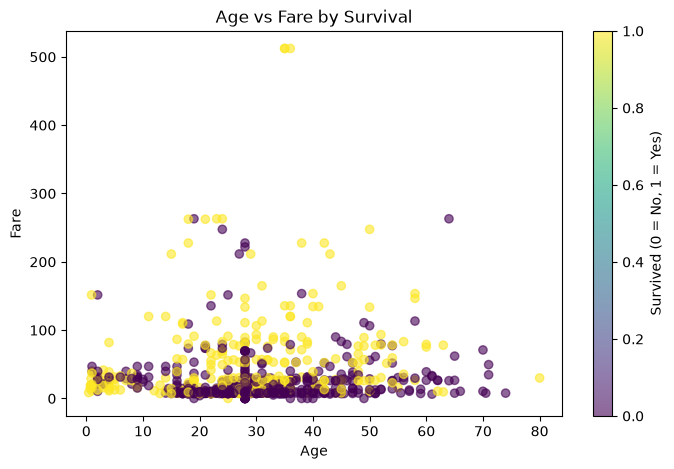

In [16]:
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    df_clean["age"],
    df_clean["fare"],
    c=df_clean["survived"],
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare by Survival")
plt.colorbar(scatter, label="Survived (0 = No, 1 = Yes)")
plt.show()

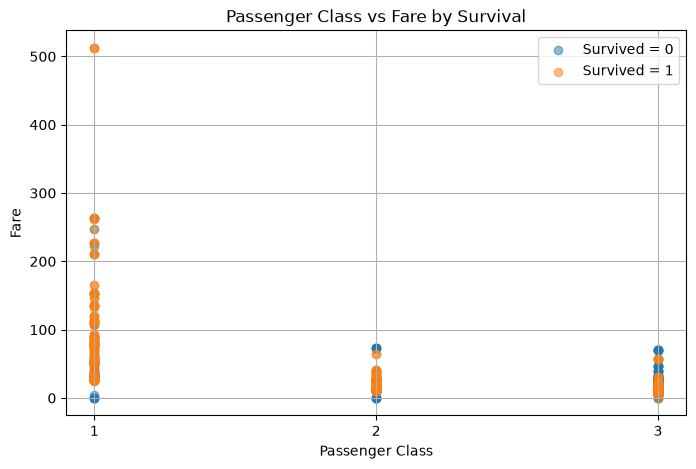

In [17]:
plt.figure(figsize=(8, 5))

for survived in [0, 1]:
    subset = df_clean[df_clean["survived"] == survived]
    plt.scatter(
        subset["pclass"],
        subset["fare"],
        alpha=0.5,
        label=f"Survived = {survived}"
    )

plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.title("Passenger Class vs Fare by Survival")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

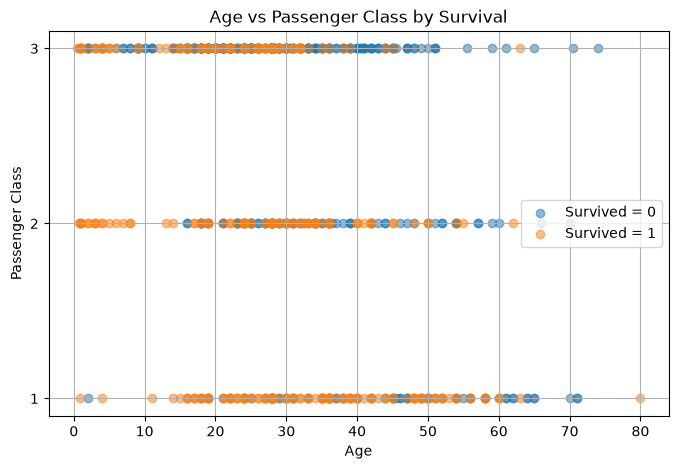

In [18]:
plt.figure(figsize=(8, 5))

for survived in [0, 1]:
    subset = df_clean[df_clean["survived"] == survived]
    
    plt.scatter(
        subset["age"],
        subset["pclass"],
        alpha=0.5,
        label=f"Survived = {survived}"
    )

plt.xlabel("Age")
plt.ylabel("Passenger Class")
plt.title("Age vs Passenger Class by Survival")
plt.yticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df_clean.copy()

df_scaled[["age_scaled", "fare_scaled"]] = scaler.fit_transform(
    df_clean[["age", "fare"]]
)

print("Before standardization:")
print("Age mean:", df_clean["age"].mean())
print("Age std:", df_clean["age"].std())
print("Fare mean:", df_clean["fare"].mean())
print("Fare std:", df_clean["fare"].std())

print("\nAfter standardization:")
print("Age scaled mean:", df_scaled["age_scaled"].mean())
print("Age scaled std:", df_scaled["age_scaled"].std())
print("Fare scaled mean:", df_scaled["fare_scaled"].mean())
print("Fare scaled std:", df_scaled["fare_scaled"].std())

Before standardization:
Age mean: 29.315151856017994
Age std: 12.984932293690775
Fare mean: 32.09668087739032
Fare std: 49.697504316707956

After standardization:
Age scaled mean: 2.717486278497571e-16
Age scaled std: 1.0005629046322504
Fare scaled mean: 1.3987061727561027e-16
Fare scaled std: 1.0005629046322506


In [20]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["survived"])
y = df_clean["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining survival distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting survival distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (711, 13)
X_test shape: (178, 13)
y_train shape: (711,)
y_test shape: (178,)

Training survival distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing survival distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [22]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [23]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [24]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        oob_score=True
    ))
])

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")
print("OOB Score:", random_forest_pipeline.named_steps["model"].oob_score_)

Random Forest trained successfully.
OOB Score: 0.8016877637130801


In [25]:
# Predictions
y_pred_logistic = logistic_pipeline.predict(X_test)
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

y_pred_tree = decision_tree_pipeline.predict(X_test)
y_prob_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = random_forest_pipeline.predict(X_test)
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Logistic predictions:", len(y_pred_logistic))
print("Decision Tree predictions:", len(y_pred_tree))
print("Random Forest predictions:", len(y_pred_rf))

Predictions generated successfully.
Logistic predictions: 178
Decision Tree predictions: 178
Random Forest predictions: 178


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics = []

models = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "Decision Tree": (y_pred_tree, y_prob_tree),
    "Random Forest": (y_pred_rf, y_prob_rf)
}

for model_name, (y_pred, y_prob) in models.items():
    metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

classification_results = pd.DataFrame(metrics)

print(classification_results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8090     0.7833  0.6912    0.7344   0.8610
1        Decision Tree    0.7640     0.7600  0.5588    0.6441   0.8374
2        Random Forest    0.8202     0.7812  0.7353    0.7576   0.8179


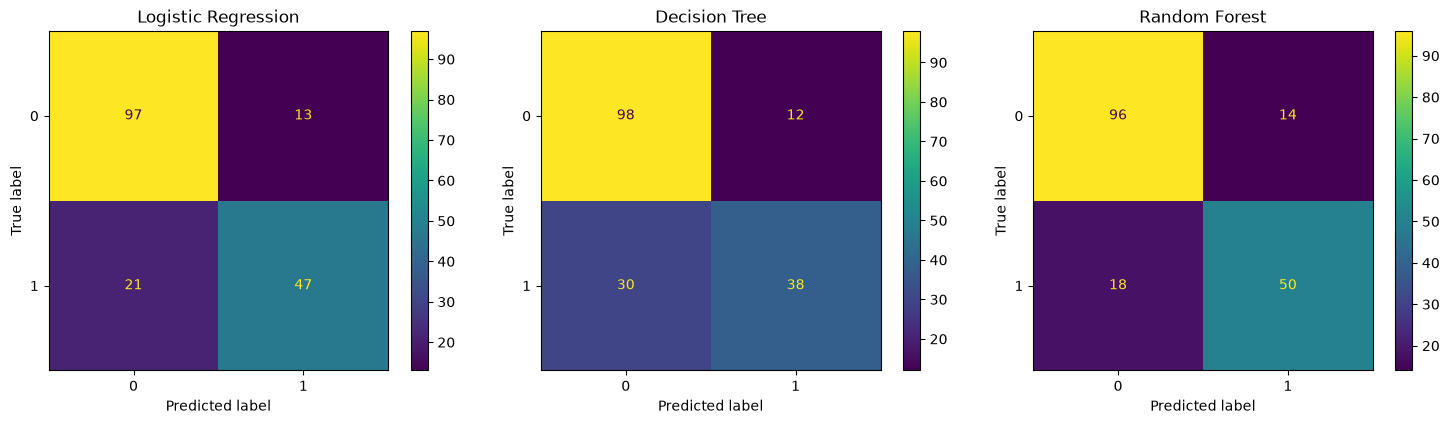

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    ax=axes[1]
)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    ax=axes[2]
)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

In [28]:
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(2))

Class counts:
survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [29]:
balanced_logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

balanced_logistic_pipeline.fit(X_train, y_train)

balanced_pred = balanced_logistic_pipeline.predict(X_test)

print("Balanced Logistic Regression trained successfully.")


Balanced Logistic Regression trained successfully.


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

print("Balanced Logistic Regression")
print("Precision:", round(balanced_precision, 4))
print("Recall:", round(balanced_recall, 4))
print("F1 Score:", round(balanced_f1, 4))

Balanced Logistic Regression
Precision: 0.7183
Recall: 0.75
F1 Score: 0.7338


In [31]:
from imblearn.over_sampling import SMOTE

# Fit preprocessing only on training data
smote_preprocessor = preprocessor

X_train_processed = smote_preprocessor.fit_transform(X_train)
X_test_processed = smote_preprocessor.transform(X_test)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original training class counts:")
print(y_train.value_counts())

print("\nAfter SMOTE training class counts:")
print(pd.Series(y_train_smote).value_counts())

print("\nTest set class counts remain unchanged:")
print(y_test.value_counts())

Original training class counts:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE training class counts:
survived
1    439
0    439
Name: count, dtype: int64

Test set class counts remain unchanged:
survived
0    110
1     68
Name: count, dtype: int64


In [32]:
smote_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_logistic_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_logistic_model.predict(X_test_processed)

print("SMOTE Logistic Regression trained successfully.")

SMOTE Logistic Regression trained successfully.


In [33]:
smote_precision = precision_score(y_test, smote_pred)
smote_recall = recall_score(y_test, smote_pred)
smote_f1 = f1_score(y_test, smote_pred)

print("SMOTE Logistic Regression")
print("Precision:", round(smote_precision, 4))
print("Recall:", round(smote_recall, 4))
print("F1 Score:", round(smote_f1, 4))

SMOTE Logistic Regression
Precision: 0.7353
Recall: 0.7353
F1 Score: 0.7353


In [34]:
balance_results = pd.DataFrame({
    "Method": [
        "Original Logistic Regression",
        "Class Weight = Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        balanced_precision,
        smote_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        balanced_recall,
        smote_recall
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        balanced_f1,
        smote_f1
    ]
})

print(balance_results.round(4))

                         Method  Precision  Recall  F1 Score
0  Original Logistic Regression     0.7833  0.6912    0.7344
1       Class Weight = Balanced     0.7183  0.7500    0.7338
2                         SMOTE     0.7353  0.7353    0.7353


### Class Imbalance Conclusion

The original Logistic Regression model achieved the highest precision (0.7833), while the class-weighted model achieved the highest recall (0.7500). SMOTE produced balanced precision and recall of 0.7353, with an F1 score of 0.7353. Class weighting and SMOTE improved recall compared with the original model, while the original model maintained higher precision.

In [35]:
from sklearn.model_selection import GridSearchCV

rf_for_grid = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully.")
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

GridSearchCV completed successfully.
Best Parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
Best CV F1 Score: 0.7408


In [36]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps["model"]

print("Best Random Forest OOB Score:", round(best_rf_model.oob_score_, 4))

Best Random Forest OOB Score: 0.8214


In [37]:
# Predictions from the tuned Random Forest
tuned_rf_pred = best_rf_pipeline.predict(X_test)
tuned_rf_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("Tuned Random Forest predictions generated successfully.")
print("Test predictions:", len(tuned_rf_pred))

Tuned Random Forest predictions generated successfully.
Test predictions: 178


In [38]:
tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)
tuned_rf_precision = precision_score(y_test, tuned_rf_pred)
tuned_rf_recall = recall_score(y_test, tuned_rf_pred)
tuned_rf_f1 = f1_score(y_test, tuned_rf_pred)
tuned_rf_auc = roc_auc_score(y_test, tuned_rf_prob)

print("Tuned Random Forest Metrics")
print("Accuracy :", round(tuned_rf_accuracy, 4))
print("Precision:", round(tuned_rf_precision, 4))
print("Recall   :", round(tuned_rf_recall, 4))
print("F1 Score :", round(tuned_rf_f1, 4))
print("ROC-AUC  :", round(tuned_rf_auc, 4))

Tuned Random Forest Metrics
Accuracy : 0.8315
Precision: 0.8654
Recall   : 0.6618
F1 Score : 0.75
ROC-AUC  : 0.8389


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features for predicting fare
regression_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked"
]

X_reg = df_clean[regression_features]
y_reg = df_clean["fare"]

# Train-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression data prepared successfully.")
print("Training shape:", X_reg_train.shape)
print("Testing shape:", X_reg_test.shape)

Regression data prepared successfully.
Training shape: (711, 6)
Testing shape: (178, 6)


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

reg_numeric_features = ["pclass", "age", "sibsp", "parch"]
reg_categorical_features = ["sex", "embarked"]

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric_features),
    ("categorical", reg_categorical_pipeline, reg_categorical_features)
])

print("Regression preprocessing pipeline created successfully.")

Regression preprocessing pipeline created successfully.


In [41]:
regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

print("Multivariate Linear Regression trained successfully.")

Multivariate Linear Regression trained successfully.


In [42]:
# Generate predictions
y_reg_pred = regression_pipeline.predict(X_reg_test)

# Regression metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print("Regression Metrics")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Regression Metrics
MAE : 21.1386
RMSE: 41.7465
R²  : 0.3468


In [43]:
# Number of test samples
n = len(y_reg_test)

# Number of predictors after preprocessing
p = regression_pipeline.named_steps["preprocessor"].get_feature_names_out().shape[0]

# Adjusted R²
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Number of observations (n):", n)
print("Number of predictors (p):", p)
print("Adjusted R²:", round(adjusted_r2, 4))

Number of observations (n): 178
Number of predictors (p): 9
Adjusted R²: 0.3118


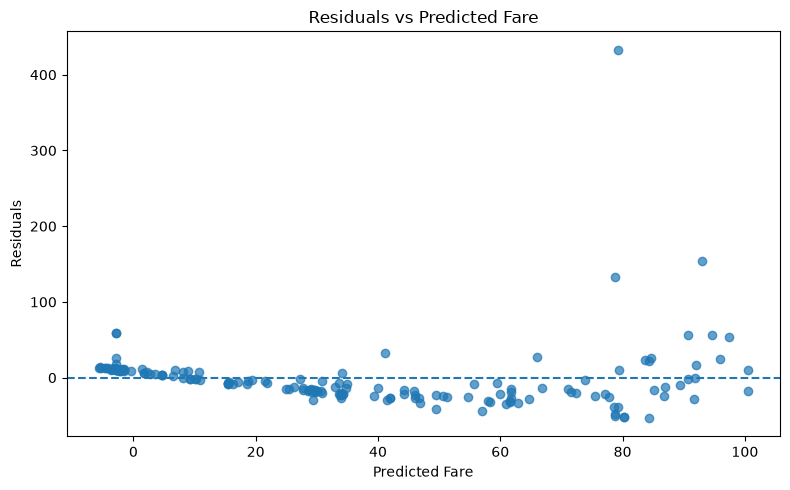

In [44]:
# Calculate residuals
residuals = y_reg_test - y_reg_pred

# Residual plot
plt.figure(figsize=(8, 5))

plt.scatter(y_reg_pred, residuals, alpha=0.7)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Fare")

plt.tight_layout()
plt.show()

### Heteroscedasticity Conclusion

The residual plot shows that the spread of residuals increases as the predicted fare increases. There are also a few large residuals at higher predicted fare values. This suggests the presence of heteroscedasticity, meaning that the residual variance is not constant across all predicted fare values.

In [45]:
# Classification results including tuned Random Forest
final_classification_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1 Score": f1_score(y_test, y_pred_logistic),
        "ROC-AUC": roc_auc_score(y_test, y_prob_logistic)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1 Score": f1_score(y_test, y_pred_tree),
        "ROC-AUC": roc_auc_score(y_test, y_prob_tree)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1 Score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": tuned_rf_accuracy,
        "Precision": tuned_rf_precision,
        "Recall": tuned_rf_recall,
        "F1 Score": tuned_rf_f1,
        "ROC-AUC": tuned_rf_auc
    }
])

print("CLASSIFICATION MODEL COMPARISON")
display(final_classification_results.round(4))

print("\nREGRESSION MODEL COMPARISON")

regression_results = pd.DataFrame([
    {
        "Model": "Multivariate Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Adjusted R²": adjusted_r2
    }
])

display(regression_results.round(4))

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179
3,Tuned Random Forest,0.8315,0.8654,0.6618,0.7500,0.8389



REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R²,Adjusted R²
0,Multivariate Linear Regression,21.1386,41.7465,0.3468,0.3118


In [46]:
print("CLASSIFICATION MODEL COMPARISON")
print(final_classification_results.round(4).to_string(index=False))

CLASSIFICATION MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8090     0.7833  0.6912    0.7344   0.8610
      Decision Tree    0.7640     0.7600  0.5588    0.6441   0.8374
      Random Forest    0.8202     0.7812  0.7353    0.7576   0.8179
Tuned Random Forest    0.8315     0.8654  0.6618    0.7500   0.8389


### Final Classifier Recommendation

The tuned Random Forest achieved the highest accuracy (0.8315), precision (0.8654), and a strong F1 score (0.7500) among the evaluated classifiers. The original Random Forest achieved the highest recall (0.7353) and F1 score (0.7576), while Logistic Regression achieved the highest ROC-AUC (0.8610). Based on the overall classification results, the tuned Random Forest is selected as the final classifier because it provides the highest accuracy and precision while maintaining a competitive F1 score. The final model will be saved as a complete pipeline containing preprocessing and the classifier.

In [47]:
import joblib

# Save the complete fitted pipeline
final_pipeline = best_rf_pipeline

joblib.dump(
    final_pipeline,
    "final_tuned_random_forest_pipeline.joblib"
)

print("Final pipeline saved successfully.")
print("File: final_tuned_random_forest_pipeline.joblib")


Final pipeline saved successfully.
File: final_tuned_random_forest_pipeline.joblib


In [48]:
# Reload the saved pipeline
loaded_pipeline = joblib.load(
    "final_tuned_random_forest_pipeline.joblib"
)

print("Pipeline reloaded successfully.")
print("Pipeline steps:", loaded_pipeline.named_steps.keys())

Pipeline reloaded successfully.
Pipeline steps: dict_keys(['preprocessor', 'model'])


In [49]:
# Create one raw passenger example
raw_input = pd.DataFrame({
    "pclass": [1],
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [80.0],
    "sex": ["female"],
    "embarked": ["S"]
})

# Prediction using the reloaded pipeline
prediction = loaded_pipeline.predict(raw_input)
probability = loaded_pipeline.predict_proba(raw_input)[0, 1]

print("Prediction:", prediction[0])
print("Survival probability:", round(probability, 4))

if prediction[0] == 1:
    print("Result: Survived")
else:
    print("Result: Did not survive")

Prediction: 1
Survival probability: 0.9676
Result: Survived


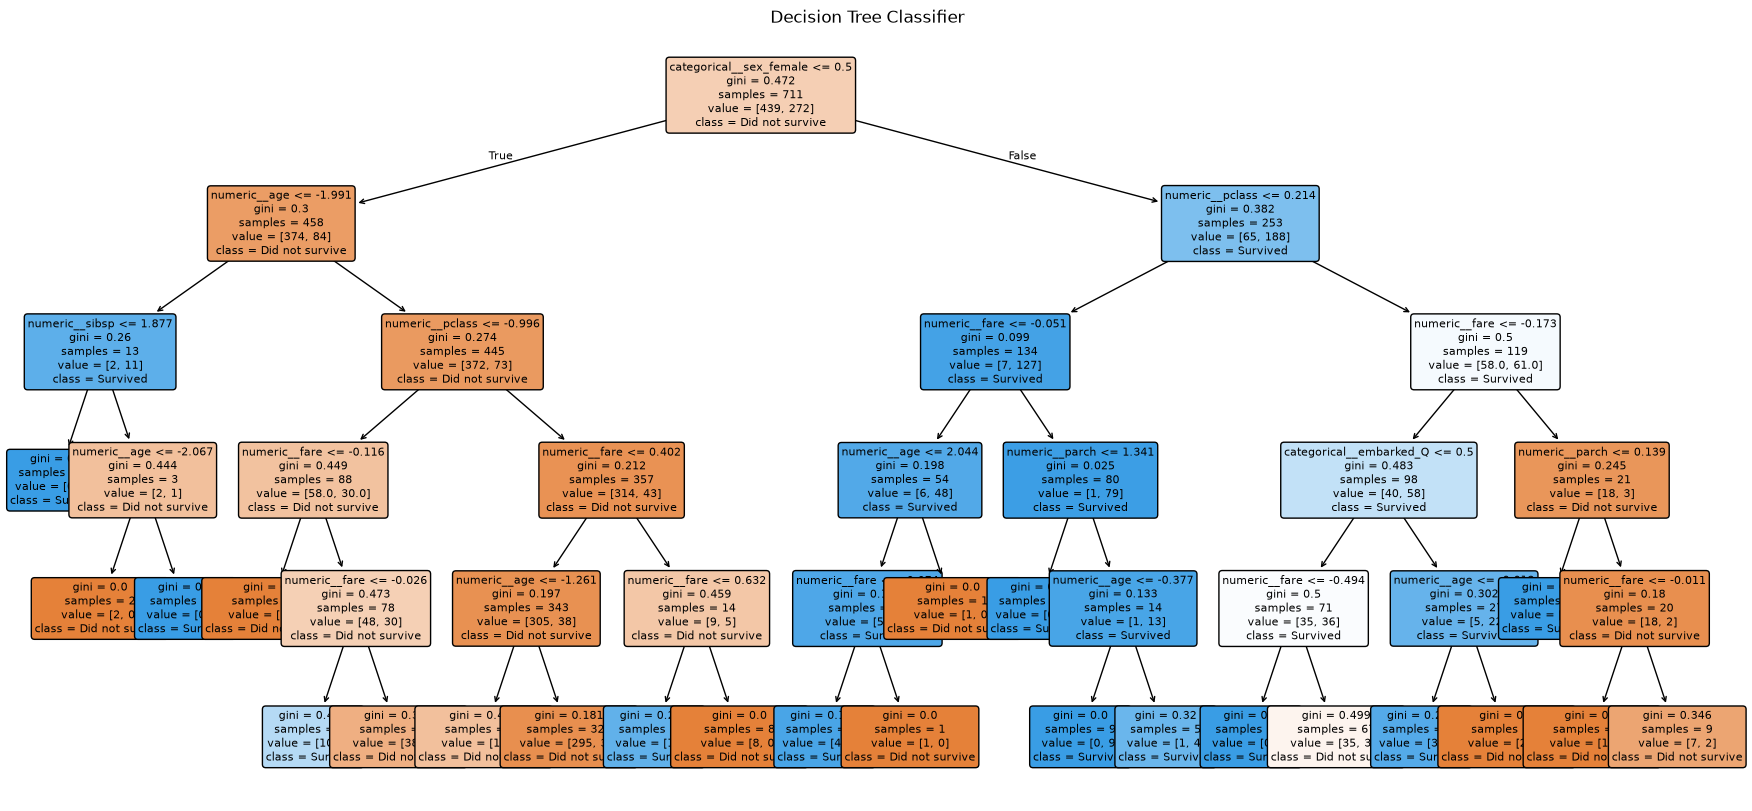

In [50]:
from sklearn.tree import plot_tree

# Get the trained decision tree and preprocessing steps
tree_model = decision_tree_pipeline.named_steps["model"]
tree_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = tree_preprocessor.get_feature_names_out()

# Plot the decision tree
plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.show()